# Chapter 08: Evaluating Explanations: Random Floors, Deletion Tests, and Judges You Haven't Checked

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mohammadi-hadi/hands-on-xai-labs/blob/main/notebooks/ch08-evaluating-explanations.ipynb)

Companion notebook for Chapter 08 of *Hands-On Explainable AI*.

**What you'll build:** the quantitative answer to Chapter 7's cliffhanger ("SHAP was unreliable here. How would you have known?"). You'll reload the Chapter 4 hate-speech specimen, explain 30 held-out tweets with LIME, SHAP, Integrated Gradients, and a random-ranking baseline, then build a reusable faithfulness harness (deletion/insertion curves, ERASER-style comprehensiveness and sufficiency, bootstrap confidence intervals) that says which rankings the model actually depends on. You'll hand-annotate human rationales to show that plausibility and faithfulness are different axes, and finish by putting a 0.5B-parameter LLM on the judge's bench: 16 rationale pairs, judged twice with the presentation order swapped, to measure exactly how often its verdict follows the slot instead of the content.

This lab is part of *Hands-On Explainable AI: Interpreting, Evaluating, and Trusting Large Language Models* by [Hadi Mohammadi](https://mohammadi.cv). Code is MIT licensed; the repository and citation info live at [hands-on-xai-labs](https://github.com/mohammadi-hadi/hands-on-xai-labs) (DOI: [10.5281/zenodo.21804605](https://doi.org/10.5281/zenodo.21804605)).

In [1]:
%%capture
import importlib.util
IN_COLAB = importlib.util.find_spec("google.colab") is not None
if IN_COLAB:
    %pip install -q transformers==4.57.6 datasets==3.6.0 shap==0.49.1 lime==0.2.0.1 captum==0.9.0

In [2]:
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from transformers import logging as hf_logging

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
hf_logging.set_verbosity_error()

# Smoke mode: CI sets BOOK_SMOKE=1 to swap in tiny budgets
SMOKE = os.environ.get("BOOK_SMOKE") == "1"
DEVICE = os.environ.get("BOOK_DEVICE") or (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

_style = Path("../styles/book.mplstyle")
if _style.exists():
    plt.style.use(_style)
INK, RUST, TEAL, AMBER, ROSE, STONE = "#1A1C1E", "#9A3412", "#0D9488", "#F59E0B", "#E11D48", "#A8A29E"
METHODS = ["LIME", "SHAP", "IG", "random"]
METHOD_COLORS = {"LIME": RUST, "SHAP": TEAL, "IG": AMBER, "random": STONE}
print(f"device={DEVICE} smoke={SMOKE}")

device=cpu smoke=False


## The bill from Chapter 7 comes due

Chapter 4 measured that LIME, SHAP, and IG only *partially* agree on the same model and the same
tweets (Kendall τ between 0.43 and 0.59). Chapter 7 went further and attacked an explanation until it
said whatever we wanted, ending on: *"SHAP was unreliable here. How would you have known?"*

This lab is the answer. The trick is to stop grading explanations by whether they **look** right
(plausibility) and start measuring whether they **are** right about the model (faithfulness): if a
ranking really names the words the classifier depends on, then deleting those words must collapse the
prediction. That's a falsifiable claim, and we can test it, with a random ranking as the floor that
every real method has to beat. In the second half we audit the newest fashion in evaluation, the
LLM-as-judge, with a miniature of the EvalMORAAL swap protocol.

> **Content note:** the tweets below come from HatEval (SemEval-2019 Task 5), a benchmark of hate
> speech directed at **women and immigrants**. Examples contain slurs and degrading language. They are
> shown verbatim because sanitizing them would change what the model, and every explanation of it,
> actually sees.

One honesty note on data selection: we draw our held-out tweets from HatEval's **validation** split,
never its test split. Chapter 4 measured the reason: the test split is topic-shifted, and the specimen
predicts "hate" on 96% of it (accuracy 0.460), while the validation split behaves sanely
(accuracy 0.676, macro-F1 0.676). Faithfulness metrics compare probabilities on perturbed inputs, so we
want tweets where the model still has both classes in play.

In [3]:
FALLBACK = [  # tiny inline stand-in so this notebook never dies offline
    ("Women like her should stay in the kitchen where they belong", 1),
    ("These immigrants are ruining our country, send them all back", 1),
    ("She only got the job because she is a woman, typical", 1),
    ("Refugees are invaders, not victims, close the border now", 1),
    ("Girls cannot do science, stop pretending otherwise", 1),
    ("Another boatload of illegals arrived today, disgusting", 1),
    ("Congratulations to my sister on her engineering degree", 0),
    ("The new immigration policy will be debated in parliament this week", 0),
    ("Volunteers welcomed the refugee families with warm meals", 0),
    ("She gave a brilliant keynote about machine learning today", 0),
    ("Our town organized a festival celebrating migrant cultures", 0),
    ("Equal pay for equal work should not be controversial", 0),
]

N_TWEETS = 8 if SMOKE else 30

try:
    from datasets import load_dataset

    ds = load_dataset("tweet_eval", "hate")
    val = ds["validation"].shuffle(seed=SEED)
    hate, nothate = [], []
    for t, y in zip(val["text"], val["label"]):
        if 10 <= len(t.split()) <= 28:  # long enough that deleting 8 words leaves a sentence
            (hate if y == 1 else nothate).append(t)
        if len(hate) >= 15 and len(nothate) >= 15:
            break
    TWEETS, LABELS = [], []
    for h, n in zip(hate[:15], nothate[:15]):  # interleave for a balanced working set
        TWEETS += [h, n]
        LABELS += [1, 0]
    print(f"tweet_eval/hate VALIDATION split: {len(TWEETS)} candidates (15 gold hate / 15 gold not)")
except Exception as e:  # offline and uncached, fall back to the inline set
    print(f"load_dataset failed ({type(e).__name__}), using 12-tweet inline fallback")
    TWEETS = [t for t, _ in FALLBACK]
    LABELS = [y for _, y in FALLBACK]

TWEETS, LABELS = TWEETS[:N_TWEETS], LABELS[:N_TWEETS]
print(f"working set: {len(TWEETS)} tweets | {int(np.sum(LABELS))} gold hate | "
      f"{np.mean([len(t.split()) for t in TWEETS]):.1f} words on average")

tweet_eval/hate VALIDATION split: 30 candidates (15 gold hate / 15 gold not)
working set: 30 tweets | 15 gold hate | 19.2 words on average


## Reload the specimen

Same weights as Chapters 4–7. Evaluating an explanation only makes sense against the exact model that
produced it. `get_specimen()` loads the saved DistilBERT checkpoint, or quick-trains a small stand-in so
the notebook stays standalone on Colab. The stand-in is a smaller model, so on Colab your numbers will differ from the printed ones; the checks and verdicts below still apply.

In [4]:
SPECIMEN_DIR = Path("../models/ch04-specimen")
ID2LABEL = {0: "not-hate", 1: "hate"}


def get_specimen():
    """Load the Chapter 4 hate/sexism specimen; quick-train a small stand-in if
    absent (keeps this notebook standalone on Colab)."""
    from transformers import AutoModelForSequenceClassification, AutoTokenizer

    if SPECIMEN_DIR.exists():
        tok = AutoTokenizer.from_pretrained(SPECIMEN_DIR)
        mdl = AutoModelForSequenceClassification.from_pretrained(SPECIMEN_DIR)
    else:
        # quick-train fallback: prajjwal1/bert-mini on tweet_eval "hate"
        # (1500 train items, 2 epochs, lr 3e-5, max_len 96, batch 32), then save
        try:
            from datasets import load_dataset

            tr = load_dataset("tweet_eval", "hate")["train"].shuffle(seed=SEED).select(range(1500))
            texts, labels = list(tr["text"]), list(tr["label"])
        except Exception:
            texts = [t for t, _ in FALLBACK] * 40
            labels = [y for _, y in FALLBACK] * 40
        tok = AutoTokenizer.from_pretrained("prajjwal1/bert-mini")
        mdl = AutoModelForSequenceClassification.from_pretrained(
            "prajjwal1/bert-mini", num_labels=2, id2label=ID2LABEL,
            label2id={v: k for k, v in ID2LABEL.items()}).to(DEVICE)
        enc = tok(texts, truncation=True, padding="max_length", max_length=96, return_tensors="pt")
        data = torch.utils.data.TensorDataset(enc["input_ids"], enc["attention_mask"], torch.tensor(labels))
        loader = torch.utils.data.DataLoader(data, batch_size=32, shuffle=True,
                                             generator=torch.Generator().manual_seed(SEED))
        opt = torch.optim.AdamW(mdl.parameters(), lr=3e-5)
        mdl.train()
        for _ in range(2):
            for ids, mask, y in loader:
                loss = mdl(input_ids=ids.to(DEVICE), attention_mask=mask.to(DEVICE), labels=y.to(DEVICE)).loss
                loss.backward()
                opt.step()
                opt.zero_grad()
        SPECIMEN_DIR.mkdir(parents=True, exist_ok=True)
        mdl.save_pretrained(SPECIMEN_DIR)
        tok.save_pretrained(SPECIMEN_DIR)
    mdl.to(DEVICE).eval()
    return tok, mdl


tok, mdl = get_specimen()
MAX_LEN = 96


def predict_proba(texts, batch_size=64):
    """Raw strings in, class probabilities out, the interface every metric below needs."""
    out = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            enc = tok(list(texts[i:i + batch_size]), truncation=True, padding=True,
                      max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
            out.append(torch.softmax(mdl(**enc).logits, dim=-1).cpu().numpy())
    return np.concatenate(out)


probs = predict_proba(TWEETS)
PREDS = probs.argmax(axis=1)
P_PRED = probs[np.arange(len(TWEETS)), PREDS]
print(f"specimen on our {len(TWEETS)} validation tweets: "
      f"accuracy {(PREDS == np.array(LABELS)).mean():.2f} | predicts hate {PREDS.mean():.0%} | "
      f"mean p(predicted label) {P_PRED.mean():.2f}")

specimen on our 30 validation tweets: accuracy 0.77 | predicts hate 60% | mean p(predicted label) 0.72


## Four rankings of the same words

We explain each tweet **toward the model's own predicted label**: faithfulness asks what the model
depends on, not what the gold label says. Alongside LIME, SHAP, and IG we add a fourth "method": a
seeded **random ranking**. Why bother? Because any faithfulness metric that can't separate a real
explainer from a shuffled one isn't measuring anything. Random is the floor of every plot below.

In [5]:
import shap
from captum.attr import LayerIntegratedGradients
from lime.lime_text import LimeTextExplainer
from transformers import pipeline

LIME_SAMPLES = 100 if SMOKE else 1000
SHAP_MAX_EVALS = 64 if SMOKE else 256
IG_STEPS = 8 if SMOKE else 32

lime_explainer = LimeTextExplainer(class_names=list(ID2LABEL.values()),
                                   split_expression=r"\s+", bow=False, random_state=SEED)


def lime_attributions(text, target):
    """LIME word attributions toward `target` (whitespace words, positional)."""
    words = text.split()
    exp = lime_explainer.explain_instance(text, predict_proba, labels=(target,),
                                          num_features=len(words), num_samples=LIME_SAMPLES)
    vals = np.zeros(len(words))
    for pos, w in exp.as_map()[target]:
        vals[pos] = w
    return vals


pipe = pipeline("text-classification", model=mdl, tokenizer=tok,
                device=DEVICE, top_k=None, batch_size=32)
shap_explainer = shap.Explainer(pipe)


def merge_subword_pieces(pieces, values):
    """Sum SHAP's sub-token pieces back into whitespace words (dropping pieces
    instead of summing them is the classic silent attribution bug, Chapter 4)."""
    words, vals, buf, acc = [], [], "", 0.0
    for piece, v in zip(pieces, values):
        if piece == "":  # [CLS]/[SEP] placeholders
            continue
        buf += piece
        acc += float(v)
        if buf.endswith(" "):
            words.append(buf.strip())
            vals.append(acc)
            buf, acc = "", 0.0
    if buf.strip():
        words.append(buf.strip())
        vals.append(acc)
    return words, np.array(vals)


def shap_attributions(texts, targets):
    """Partition-SHAP word attributions toward each text's target label."""
    sv = shap_explainer(list(texts), max_evals=SHAP_MAX_EVALS, silent=True)
    out = []
    for k, (t, tgt) in enumerate(zip(texts, targets)):
        col = list(sv.output_names).index(ID2LABEL[tgt])
        words, vals = merge_subword_pieces(sv.data[k], sv.values[k][:, col])
        assert words == t.split(), f"word merge mismatch on tweet {k}"
        out.append(vals)
    return out


lig = LayerIntegratedGradients(lambda ids, mask: mdl(input_ids=ids, attention_mask=mask).logits,
                               mdl.get_input_embeddings())


def ig_attributions(text, target):
    """IG word attributions: sum embedding dims, then sum sub-words into words."""
    words = text.split()
    enc = tok([words], is_split_into_words=True, truncation=True,
              max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
    ids, mask = enc["input_ids"], enc["attention_mask"]
    keep = (ids == tok.cls_token_id) | (ids == tok.sep_token_id)
    baseline = torch.where(keep, ids, torch.full_like(ids, tok.pad_token_id))
    attr = lig.attribute(ids, baselines=baseline, additional_forward_args=(mask,),
                         target=target, n_steps=IG_STEPS, internal_batch_size=16)
    token_attr = attr.sum(dim=-1)[0].detach().cpu().numpy()
    vals = np.zeros(len(words))
    for a, wid in zip(token_attr, enc.word_ids(0)):
        if wid is not None:
            vals[wid] += a
    return vals


def random_attributions(text, seed):
    """The floor every metric must beat: a seeded random ranking."""
    rng = np.random.default_rng(seed)
    return rng.standard_normal(len(text.split()))

In [6]:
targets = [int(p) for p in PREDS]
ATTR, TIMINGS = {}, {}

t0 = time.perf_counter()
ATTR["LIME"] = [lime_attributions(t, y) for t, y in zip(TWEETS, targets)]
TIMINGS["LIME"] = time.perf_counter() - t0

t0 = time.perf_counter()
ATTR["SHAP"] = shap_attributions(TWEETS, targets)
TIMINGS["SHAP"] = time.perf_counter() - t0

t0 = time.perf_counter()
ATTR["IG"] = [ig_attributions(t, y) for t, y in zip(TWEETS, targets)]
TIMINGS["IG"] = time.perf_counter() - t0

ATTR["random"] = [random_attributions(t, SEED + i) for i, t in enumerate(TWEETS)]
TIMINGS["random"] = 0.0

for m in METHODS:
    print(f"{m:>7s}: {TIMINGS[m]:5.1f}s for {len(TWEETS)} tweets")
ex = targets.index(1) if 1 in targets else 0  # showcase a hate-predicted tweet
w_ex = TWEETS[ex].split()
print(f'\nexample, "{TWEETS[ex][:70]}..." (p({ID2LABEL[targets[ex]]})={P_PRED[ex]:.2f})')
for m in ["LIME", "SHAP", "IG"]:
    top = np.argsort(-np.asarray(ATTR[m][ex]))[:3]
    print(f"  {m:>4s} top-3 toward predicted label: {[w_ex[j] for j in top]}")

   LIME:  86.0s for 30 tweets
   SHAP:  21.5s for 30 tweets
     IG:   3.1s for 30 tweets
 random:   0.0s for 30 tweets

example, "Niggas be like your pussy bald? You must want a pornstair 24/7 stfu..." (p(hate)=0.75)
  LIME top-3 toward predicted label: ['pussy', 'want', 'be']
  SHAP top-3 toward predicted label: ['pussy', 'Niggas', 'stfu']
    IG top-3 toward predicted label: ['pussy', 'pornstair', 'bald?']


## The faithfulness harness

Two perturbation games, both falsifiable:

- **Deletion**: remove the top-*k* attributed words and watch p(predicted label). If the ranking is
  faithful, confidence falls fast; the **area under the deletion curve** (lower = better) summarizes it.
- **Insertion**: show the model *only* the top-*k* words. Faithful rankings rebuild confidence fast.

From the same curves we get the two ERASER-style point metrics: **comprehensiveness@k**
(confidence lost when the top-k words are removed; higher is better) and **sufficiency@k**
(confidence lost when only the top-k remain; lower is better). Thirty tweets is a small sample, so
every score below carries a percentile-bootstrap 95% CI; Chapter 9 reuses `bootstrap_ci` verbatim, and
Chapter 12 re-imports the deletion idea as a training signal.

In [7]:
K_MAX = 8


def rank_order(attr):
    """Word positions sorted by attribution toward the target label, strongest first."""
    return np.argsort(-np.asarray(attr), kind="stable")


def delete_topk(text, order, k):
    """Remove the k highest-attribution words; keep the rest in original order."""
    drop = set(order[:k].tolist())
    return " ".join(w for i, w in enumerate(text.split()) if i not in drop)


def keep_topk(text, order, k):
    """Keep only the k highest-attribution words, in original order."""
    keep = set(order[:k].tolist())
    return " ".join(w for i, w in enumerate(text.split()) if i in keep)


def deletion_insertion_curves(text, attr, target, k_max=K_MAX):
    """Deletion and insertion curves for one text under one attribution vector.

    Deletion: p(target) after removing the top-k attributed words, k = 0..k_max , 
    a faithful ranking makes this fall fast. Insertion: p(target) when ONLY the
    top-k words are shown, a faithful ranking makes this rise fast.
    Returns (del_probs, ins_probs), each of length k_max + 1; deletion index 0 is
    the original text, insertion index 0 the empty string.
    """
    order = rank_order(attr)
    ks = range(k_max + 1)
    variants = [delete_topk(text, order, k) for k in ks] + [keep_topk(text, order, k) for k in ks]
    p = predict_proba(variants)[:, target]
    return p[:k_max + 1], p[k_max + 1:]


def curve_auc(probs):
    """Area under a deletion/insertion curve, k axis normalised to [0, 1]."""
    return float(np.trapz(probs, dx=1.0 / (len(probs) - 1)))


def comprehensiveness(p_full, del_probs, k):
    """ERASER comprehensiveness@k: confidence the top-k words take with them (higher = more faithful)."""
    return float(p_full - del_probs[k])


def sufficiency(p_full, ins_probs, k):
    """ERASER sufficiency@k: confidence lost when ONLY the top-k words remain (lower = more faithful)."""
    return float(p_full - ins_probs[k])


def bootstrap_ci(values, n_boot=2000, alpha=0.05, seed=SEED):
    """Percentile-bootstrap CI for the mean of `values`. Returns (mean, lo, hi).

    Chapter 9 reuses this exact function for CoT-faithfulness scores.
    """
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    means = rng.choice(values, size=(n_boot, len(values)), replace=True).mean(axis=1)
    lo, hi = np.quantile(means, [alpha / 2, 1 - alpha / 2])
    return float(values.mean()), float(lo), float(hi)


t0 = time.perf_counter()
DEL, INS = {}, {}
for m in METHODS:
    dd, ii = [], []
    for i, t in enumerate(TWEETS):
        d, s = deletion_insertion_curves(t, ATTR[m][i], targets[i])
        dd.append(d)
        ii.append(s)
    DEL[m], INS[m] = np.array(dd), np.array(ii)
print(f"curves: {len(METHODS)} methods x {len(TWEETS)} tweets x {2 * (K_MAX + 1)} variants "
      f"in {time.perf_counter() - t0:.1f}s")

curves: 4 methods x 30 tweets x 18 variants in 3.0s


In [8]:
# Chapter 5 promised this harness could score attention too; pay that debt here.
# The ranking uses ch05's reading convention: LAST layer, MEAN over heads, the
# [CLS] row. Sub-word attention mass is summed into whitespace words with the
# same word_ids trick as ig_attributions above, so attention ranks exactly the
# word units the deletion/insertion machinery perturbs. Attention is not an
# attribution method, but it is a ranking, and the harness scores rankings.


def attention_attributions(text):
    """[CLS]-row attention (last layer, head-averaged) summed into whitespace words."""
    words = text.split()
    enc = tok([words], is_split_into_words=True, truncation=True,
              max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = mdl(**enc, output_attentions=True)  # SDPA falls back to eager for this
    cls_att = out.attentions[-1][0].mean(0)[0].cpu().numpy()  # attention FROM [CLS]
    vals = np.zeros(len(words))
    for a_tok, wid in zip(cls_att, enc.word_ids(0)):
        if wid is not None:  # drops [CLS]/[SEP], same guard as ig_attributions
            vals[wid] += a_tok
    return vals


_attn_t0 = time.perf_counter()
ATTN_ATTR = [attention_attributions(_t) for _t in TWEETS]
ATTN_SECONDS = time.perf_counter() - _attn_t0
assert all(len(_a) == len(_t.split()) for _a, _t in zip(ATTN_ATTR, TWEETS)), "attention/word misalignment"

_attn_t0 = time.perf_counter()
_attn_dd, _attn_ii = [], []
for _i, _t in enumerate(TWEETS):
    _d, _s = deletion_insertion_curves(_t, ATTN_ATTR[_i], targets[_i])
    _attn_dd.append(_d)
    _attn_ii.append(_s)
ATTN_DEL, ATTN_INS = np.array(_attn_dd), np.array(_attn_ii)
ATTN_CURVE_SECONDS = time.perf_counter() - _attn_t0


def _auc_ci(curves):
    return bootstrap_ci([curve_auc(_c) for _c in curves])


def _ci_fmt(ci):
    return f"{ci[0]:.3f} [{ci[1]:.3f}, {ci[2]:.3f}]"


ATTN_AUC = _auc_ci(ATTN_DEL)
_peers = {_m: _auc_ci(DEL[_m]) for _m in METHODS}

print(f"attention ranking (last layer, head-mean, [CLS] row): {ATTN_SECONDS:.1f}s for "
      f"{len(TWEETS)} tweets (one forward each), "
      f"{ATTN_CURVE_SECONDS:.1f}s for its {len(TWEETS) * 2 * (K_MAX + 1)} harness variants")
_attn_top = np.argsort(-ATTN_ATTR[ex])[:3]
print(f"attention top-3 on the same example tweet: {[w_ex[_j] for _j in _attn_top]}")
print(f"\nattention deletion-AUC {_ci_fmt(ATTN_AUC)} | "
      + " · ".join(f"{_m} {_ci_fmt(_peers[_m])}" for _m in METHODS))
_sep_bits = []
for _m in METHODS:
    _o = _peers[_m]
    _sep_bits.append(f"vs {_m}: " + ("OVERLAP" if not (ATTN_AUC[2] < _o[1] or _o[2] < ATTN_AUC[1]) else "separated"))
print("CI separation, attention " + " · ".join(_sep_bits))


attention ranking (last layer, head-mean, [CLS] row): 0.2s for 30 tweets (one forward each), 0.8s for its 540 harness variants
attention top-3 on the same example tweet: ['Niggas', 'stfu', 'pornstair']

attention deletion-AUC 0.648 [0.605, 0.692] | LIME 0.495 [0.450, 0.545] · SHAP 0.526 [0.480, 0.578] · IG 0.543 [0.497, 0.594] · random 0.678 [0.629, 0.728]
CI separation, attention vs LIME: separated · vs SHAP: separated · vs IG: separated · vs random: OVERLAP


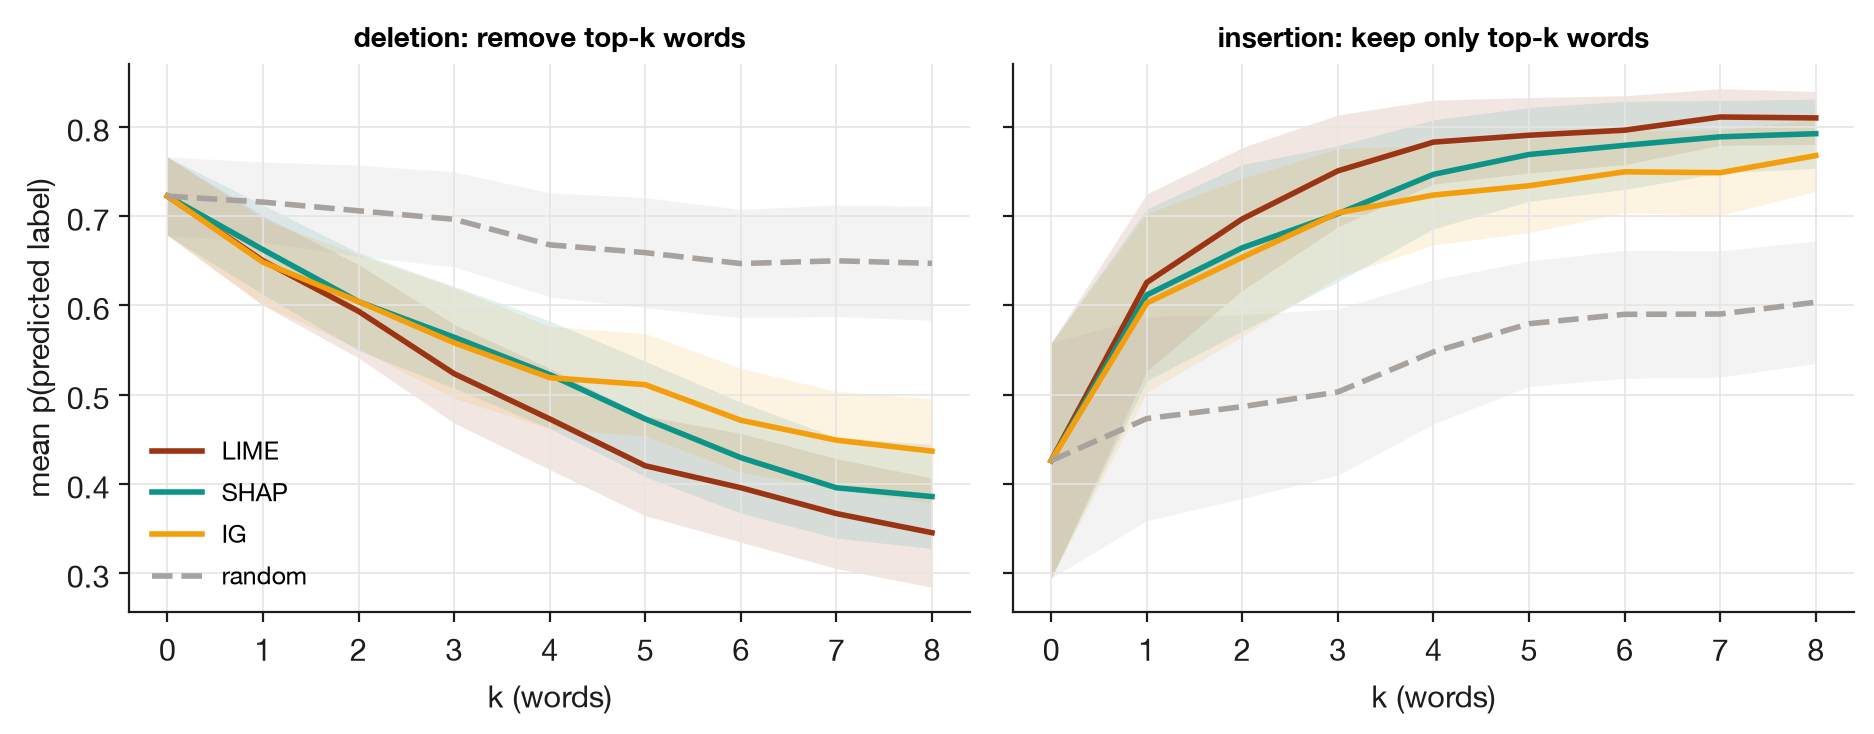

In [9]:
#| label: fig-deletion-curves
#| fig-cap: "Deletion (left) and insertion (right) curves for LIME, SHAP, IG, and a random ranking on 30 validation tweets: faithful rankings fall faster when their top words are removed and rise faster when only those words are shown; the dashed random floor is what an uninformative ranking buys."
#| fig-alt: "Deletion and insertion curves for LIME, SHAP, Integrated Gradients, and a random ranking: faithful rankings drop the probability fastest under deletion and restore it fastest under insertion."
ks = np.arange(K_MAX + 1)
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), sharey=True)
for ax, curves, title in ((axes[0], DEL, "deletion: remove top-k words"),
                          (axes[1], INS, "insertion: keep only top-k words")):
    for m in METHODS:
        mean = curves[m].mean(axis=0)
        sem = curves[m].std(axis=0, ddof=1) / np.sqrt(len(TWEETS))
        ls = "--" if m == "random" else "-"
        ax.plot(ks, mean, ls, color=METHOD_COLORS[m], label=m, linewidth=2)
        ax.fill_between(ks, mean - 1.96 * sem, mean + 1.96 * sem,
                        color=METHOD_COLORS[m], alpha=0.12, linewidth=0)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("k (words)")
axes[0].set_ylabel("mean p(predicted label)")
axes[0].legend(fontsize=9)
plt.tight_layout()
plt.show()

## So which method wins?

One number per method and metric, each with its bootstrap 95% CI over the tweets. The honest question
is not just "who is lowest?" but "**do the intervals even separate?**" With n = 30, they often don't,
and that is a finding about sample size, not a bug.

One escalation is available when the marginal intervals refuse to rank a pair: every ranking was scored on the *same* thirty tweets, so the scores pair up tweet-by-tweet, and a bootstrap over the per-tweet *differences* asks the sharper question.

In [10]:
DEL_AUC = {m: [curve_auc(c) for c in DEL[m]] for m in METHODS}
COMP = {m: {k: [comprehensiveness(DEL[m][i, 0], DEL[m][i], k) for i in range(len(TWEETS))]
            for k in (1, 3, 5)} for m in METHODS}
SUFF = {m: {k: [sufficiency(DEL[m][i, 0], INS[m][i], k) for i in range(len(TWEETS))]
            for k in (1, 3, 5)} for m in METHODS}

CI = {m: {"auc": bootstrap_ci(DEL_AUC[m]), "comp5": bootstrap_ci(COMP[m][5])} for m in METHODS}

print(f"{'method':>7s} | {'deletion-AUC (lower=faithful)':>31s} | comp@1 / comp@3 / comp@5 | suff@1 / suff@3 / suff@5")
for m in METHODS:
    a, lo, hi = CI[m]["auc"]
    c = [np.mean(COMP[m][k]) for k in (1, 3, 5)]
    s = [np.mean(SUFF[m][k]) for k in (1, 3, 5)]
    print(f"{m:>7s} | {a:.3f}  [{lo:.3f}, {hi:.3f}]         | "
          f"{c[0]:.3f} / {c[1]:.3f} / {c[2]:.3f}    | {s[0]:.3f} / {s[1]:.3f} / {s[2]:.3f}")


def ci_overlap(ci1, ci2):
    """True when two (mean, lo, hi) intervals overlap, i.e. we cannot rank the pair."""
    return not (ci1[2] < ci2[1] or ci2[2] < ci1[1])


print("\nCI separation on deletion-AUC (the sample-size lesson):")
for a, b in [("LIME", "random"), ("SHAP", "random"), ("IG", "random"),
             ("LIME", "SHAP"), ("LIME", "IG"), ("SHAP", "IG")]:
    verdict = "OVERLAP, cannot rank this pair at n=30" if ci_overlap(CI[a]["auc"], CI[b]["auc"]) else "separated"
    print(f"  {a:>4s} vs {b:<6s}: {verdict}")

 method |   deletion-AUC (lower=faithful) | comp@1 / comp@3 / comp@5 | suff@1 / suff@3 / suff@5
   LIME | 0.495  [0.450, 0.545]         | 0.072 / 0.199 / 0.302    | 0.097 / -0.028 / -0.068
   SHAP | 0.526  [0.480, 0.578]         | 0.060 / 0.158 / 0.250    | 0.111 / 0.020 / -0.047
     IG | 0.543  [0.497, 0.594]         | 0.074 / 0.164 / 0.211    | 0.120 / 0.019 / -0.012
 random | 0.678  [0.629, 0.728]         | 0.007 / 0.026 / 0.063    | 0.249 / 0.220 / 0.143

CI separation on deletion-AUC (the sample-size lesson):
  LIME vs random: separated
  SHAP vs random: separated
    IG vs random: separated
  LIME vs SHAP  : OVERLAP, cannot rank this pair at n=30
  LIME vs IG    : OVERLAP, cannot rank this pair at n=30
  SHAP vs IG    : OVERLAP, cannot rank this pair at n=30


In [11]:
# The paired escalation: marginal CIs compare two noisy interval estimates, but the
# per-tweet AUCs line up one-to-one, so the difference is the cleaner statistic.
ATTN_AUC = [curve_auc(c) for c in _attn_dd]
AUCS = dict(DEL_AUC, attention=ATTN_AUC)
PAIRS = [("LIME", "SHAP"), ("LIME", "IG"), ("SHAP", "IG"),
         ("LIME", "random"), ("SHAP", "random"), ("IG", "random"),
         ("attention", "random")]
print("paired-difference bootstrap on deletion-AUC (negative = first ranking more faithful):")
PAIRED = {}
for a, b in PAIRS:
    diffs = np.asarray(AUCS[a]) - np.asarray(AUCS[b])
    mean, lo, hi = bootstrap_ci(diffs)
    PAIRED[(a, b)] = (mean, lo, hi)
    verdict = "separated" if (hi < 0 or lo > 0) else "still overlaps zero"
    print(f"  {a:>9s} - {b:<9s}: {mean:+.3f}  [{lo:+.3f}, {hi:+.3f}]  {verdict}")


paired-difference bootstrap on deletion-AUC (negative = first ranking more faithful):
       LIME - SHAP     : -0.031  [-0.066, +0.001]  still overlaps zero
       LIME - IG       : -0.048  [-0.072, -0.027]  separated
       SHAP - IG       : -0.017  [-0.044, +0.013]  still overlaps zero
       LIME - random   : -0.184  [-0.220, -0.150]  separated
       SHAP - random   : -0.153  [-0.197, -0.112]  separated
         IG - random   : -0.136  [-0.169, -0.105]  separated
  attention - random   : -0.031  [-0.075, +0.012]  still overlaps zero


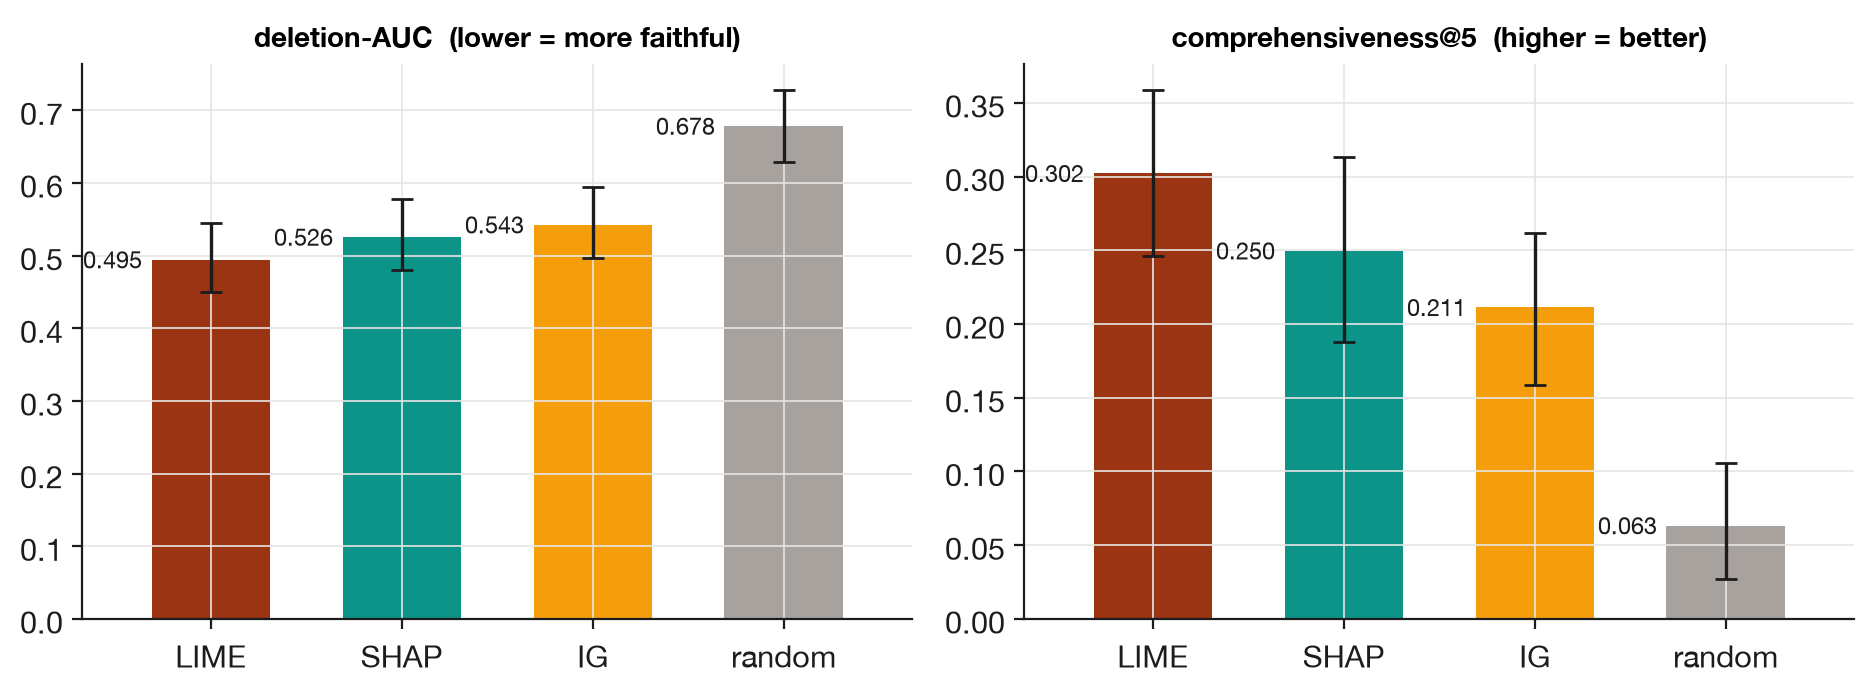

In [12]:
#| label: fig-faithfulness-ranking
#| fig-cap: "Faithfulness league table with uncertainty: deletion-AUC (left, lower is more faithful) and comprehensiveness@5 (right, higher is better) with percentile-bootstrap 95% CIs over 30 tweets. Whether the real methods separate from the random floor, and from each other, is a sample-size question the intervals answer honestly."
#| fig-alt: "Dot-and-whisker panels of deletion AUC and comprehensiveness at five per method with percentile intervals: every method clears the random floor."
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6))
x = np.arange(len(METHODS))
for ax, vals, title in (
    (axes[0], DEL_AUC, "deletion-AUC  (lower = more faithful)"),
    (axes[1], {m: COMP[m][5] for m in METHODS}, "comprehensiveness@5  (higher = better)"),
):
    means, los, his = zip(*[bootstrap_ci(vals[m]) for m in METHODS])
    err = np.array([np.array(means) - np.array(los), np.array(his) - np.array(means)])
    ax.bar(x, means, color=[METHOD_COLORS[m] for m in METHODS], width=0.62)
    ax.errorbar(x, means, yerr=err, fmt="none", ecolor=INK, elinewidth=1.2, capsize=4)
    for xi, v in zip(x, means):
        ax.text(xi - 0.36, v, f"{v:.3f}", ha="right", va="center", fontsize=8.5, color=INK)
    ax.margins(x=0.10)
    ax.set_xticks(x)
    ax.set_xticklabels(METHODS)
    ax.set_title(title, fontsize=10)
plt.tight_layout()
plt.show()

## Plausibility is not faithfulness

Faithfulness asks "does the *model* rely on these words?". Plausibility asks "would a *human* pick
them?". Chapter 7 built an explanation that was maximally plausible and a complete lie, so we measure
the two on separate axes. Below we hand-annotate rationale words for 8 of the hateful tweets (the words
a human moderator would highlight as evidence of hate) and score each method's top-k words against them
with token-F1. The annotation took ten minutes of human time; that's the point: plausibility is cheap
to measure and *still* not a substitute for faithfulness.

In [13]:
# Human rationales (whitespace tokens, exactly as they appear in the tweet).
# Annotated by the author: the words a content moderator would highlight as hate evidence.
RATIONALES = {
    "@user @user Wow, I had no idea calling Booker and Harris hysterical women was racist. "
    "Amazing how things get redefined on a daily basis.": ["hysterical", "women"],
    "Niggas be like your pussy bald? You must want a pornstair 24/7 stfu": ["Niggas", "pussy", "stfu"],
    "my reaction when literally all the girls in my class telling me that im so tall. "
    "bitch u better stfu i dont need ur validation hoe": ["bitch", "stfu", "hoe"],
    "@user @user ME: h-You: BITCH STFU ILYM STUPID DUMB HOE !!": ["BITCH", "DUMB", "HOE"],
    "U MOTHERFUCKING BITCH DIDNT TELL ME I COULD MOVE MY KING CHIPS WHEN I HAD F O UR "
    "AND YOU HAD NONE. CHEATING ASS HOE.": ["MOTHERFUCKING", "BITCH", "HOE."],
    "shut the fuck up you stupud fucking edater , go get some fucking pussy irl "
    "you dumb muslim": ["stupud", "dumb", "muslim"],
    "Hi bitch pls @ Us skank ass hoe you aint bouta to do shit but we can throw hands "
    "tomorrow since you so bold on twitter": ["bitch", "skank", "hoe"],
    "LaPlace,La. Illegal Alien arrested on a 2nd degree attempted murder charge for Machete attack. "
    "@user #BuildTheWallNow #NoAmnesty #NoDACA#DeportThemAll "
    "#KeepAmericaSafe": ["Illegal", "Alien", "#NoDACA#DeportThemAll"],
    "@user Dont worry Ann. No one will ever accuse you of being a hysterical woman "
    "or any kind of woman": ["hysterical", "woman"],
    # fallback tweets, so the offline path still has annotations
    "Women like her should stay in the kitchen where they belong": ["Women", "kitchen"],
    "These immigrants are ruining our country, send them all back": ["immigrants", "ruining"],
    "She only got the job because she is a woman, typical": ["woman,", "typical"],
    "Girls cannot do science, stop pretending otherwise": ["Girls", "cannot"],
}

ANNOTATED = []
for i, t in enumerate(TWEETS):
    if t in RATIONALES:
        assert all(w in t.split() for w in RATIONALES[t]), f"rationale word not in tweet {i}"
        if targets[i] == 1:  # rationales mark hate evidence; keep only hate predictions
            ANNOTATED.append(i)
        else:
            print(f"skipping tweet {i} (model predicted not-hate)")
print(f"{len(ANNOTATED)} annotated tweets in the working set")


def plausibility_f1(attr, words, rationale):
    """Token-F1 between the top-|rationale| attributed words and the human rationale."""
    gold = set(rationale)
    pred = []
    for idx in rank_order(attr):
        if words[idx] not in pred:
            pred.append(words[idx])
        if len(pred) == len(gold):
            break
    tp = len(set(pred) & gold)
    if tp == 0:
        return 0.0
    prec, rec = tp / len(pred), tp / len(gold)
    return 2 * prec * rec / (prec + rec)


PLAUS = {m: float(np.mean([plausibility_f1(ATTR[m][i], TWEETS[i].split(), RATIONALES[TWEETS[i]])
                           for i in ANNOTATED])) for m in METHODS}
FAITH5 = {m: float(np.mean(COMP[m][5])) for m in METHODS}
print(f"\n{'method':>7s} | plausibility (token-F1 vs {len(ANNOTATED)} rationales) | faithfulness (comp@5, all tweets)")
for m in METHODS:
    print(f"{m:>7s} | {PLAUS[m]:.2f}{' ' * 37}| {FAITH5[m]:.3f}")

skipping tweet 0 (model predicted not-hate)
8 annotated tweets in the working set

 method | plausibility (token-F1 vs 8 rationales) | faithfulness (comp@5, all tweets)
   LIME | 0.52                                     | 0.302
   SHAP | 0.50                                     | 0.250
     IG | 0.46                                     | 0.211
 random | 0.17                                     | 0.063


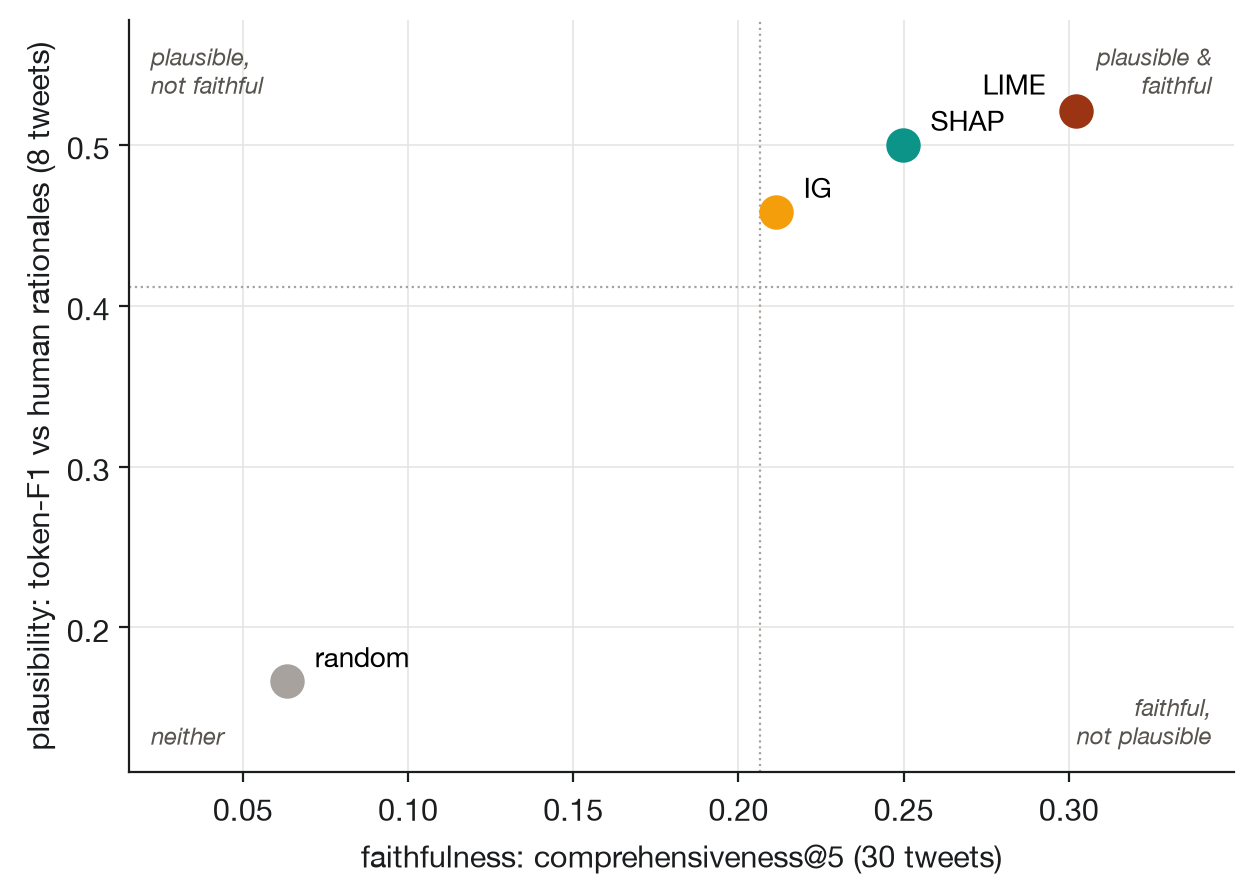

In [14]:
#| label: fig-plausibility-vs-faithfulness
#| fig-cap: "The chapter's 2x2, measured: agreement with human rationales (plausibility, y) against comprehensiveness@5 (faithfulness, x) for each method. The two axes are different questions, and a method can score well on one without the other."
#| fig-alt: "Scatter of methods with plausibility on the y axis and comprehensiveness at five on the x axis: the two properties do not rank the methods the same way."
fig, ax = plt.subplots(figsize=(6.4, 4.6))
xs, ys = list(FAITH5.values()), list(PLAUS.values())
for m in METHODS:
    ax.scatter(FAITH5[m], PLAUS[m], s=130, color=METHOD_COLORS[m], zorder=3)
    right_edge = FAITH5[m] == max(xs)
    ax.annotate(m, (FAITH5[m], PLAUS[m]), textcoords="offset points",
                xytext=(-11, 6) if right_edge else (10, 5),
                ha="right" if right_edge else "left", fontsize=10)
xpad, ypad = (max(xs) - min(xs)) * 0.20, (max(ys) - min(ys)) * 0.16
ax.set_xlim(min(xs) - xpad, max(xs) + xpad)
ax.set_ylim(min(ys) - ypad, max(ys) + ypad)
xm = np.mean(xs)
ym = np.mean(ys)
ax.axvline(xm, color=STONE, linewidth=0.8, linestyle=":")
ax.axhline(ym, color=STONE, linewidth=0.8, linestyle=":")
GRAPHITE = "#57534E"  # secondary text
for tx, ty, s, va, ha in ((0.02, 0.97, "plausible,\nnot faithful", "top", "left"),
                          (0.98, 0.97, "plausible &\nfaithful", "top", "right"),
                          (0.02, 0.03, "neither", "bottom", "left"),
                          (0.98, 0.03, "faithful,\nnot plausible", "bottom", "right")):
    ax.text(tx, ty, s, transform=ax.transAxes, fontsize=8.5, color=GRAPHITE,
            style="italic", va=va, ha=ha)
ax.set_xlabel(f"faithfulness: comprehensiveness@5 ({len(TWEETS)} tweets)")
ax.set_ylabel(f"plausibility: token-F1 vs human rationales ({len(ANNOTATED)} tweets)")
plt.tight_layout()
plt.show()

## Auditing the judge: an EvalMORAAL miniature

The newest evaluation shortcut is to let an LLM grade explanations. Cheap, scalable. And the judge is
now part of your measurement instrument, so it needs calibrating like one. We run the smallest audit
that produces a number: rationale **pairs** (the human rationale vs. the same sentence template stuffed
with random words from the tweet), judged twice with the **presentation order swapped**. A judge that
reads content gives the same verdict both times; a judge that follows the slot letter reveals
**position bias**. We use a deliberately small judge (Qwen2.5-0.5B-Instruct, CPU, greedy decoding):
the point is to catch a judge failing, and to prove the audit *can* catch it.

In [15]:
from transformers import AutoModelForCausalLM, AutoTokenizer

JUDGE_ID = "Qwen/Qwen2.5-0.5B-Instruct"
t0 = time.perf_counter()
judge_tok = AutoTokenizer.from_pretrained(JUDGE_ID)
judge_mdl = AutoModelForCausalLM.from_pretrained(JUDGE_ID, dtype=torch.float32).to(DEVICE).eval()
for name in ("temperature", "top_p", "top_k"):  # greedy decoding: silence sampling-flag warnings
    setattr(judge_mdl.generation_config, name, None)
print(f"judge loaded: {JUDGE_ID} in {time.perf_counter() - t0:.1f}s on {DEVICE}")


def judge_verdict(tweet, expl_a, expl_b):
    """Ask the judge which explanation better supports the hate label. Returns 'A', 'B', or '?'."""
    user = (f'Tweet: "{tweet}"\n'
            "A classifier labeled this tweet: hate.\n\n"
            f"Explanation A: {expl_a}\n"
            f"Explanation B: {expl_b}\n\n"
            "Which explanation better supports the label? Answer with exactly one letter: A or B.")
    prompt = judge_tok.apply_chat_template([{"role": "user", "content": user}],
                                           tokenize=False, add_generation_prompt=True)
    enc = judge_tok(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = judge_mdl.generate(**enc, max_new_tokens=6, do_sample=False,
                                 pad_token_id=judge_tok.eos_token_id)
    reply = judge_tok.decode(out[0, enc["input_ids"].shape[1]:], skip_special_tokens=True).strip().upper()
    for ch in reply:
        if ch in "AB":
            return ch
    return "?"


def explanation_text(words):
    """Both pair members use this same template, only the word list differs, so style can't leak."""
    return "The tweet was labeled hate because of the words: " + ", ".join(f'"{w}"' for w in words) + "."


N_PAIRS = 6 if SMOKE else 16
rng = np.random.default_rng(SEED)
PAIRS = []
for i in ANNOTATED:
    rationale = RATIONALES[TWEETS[i]]
    pool = [w for w in TWEETS[i].split() if w not in rationale and len(w) > 2 and not w.startswith("@")]
    for _ in range(2):  # two distractor draws per tweet
        distract = list(rng.choice(pool, size=min(len(rationale), len(pool)), replace=False))
        PAIRS.append({"tweet": TWEETS[i], "good": explanation_text(rationale),
                      "bad": explanation_text(distract)})
PAIRS = PAIRS[:N_PAIRS]
print(f"{len(PAIRS)} rationale pairs (human rationale vs shuffled tweet words)")
print("example pair:")
print("  good:", PAIRS[0]["good"])
print("  bad: ", PAIRS[0]["bad"])

judge loaded: Qwen/Qwen2.5-0.5B-Instruct in 2.0s on cpu
16 rationale pairs (human rationale vs shuffled tweet words)
example pair:
  good: The tweet was labeled hate because of the words: "Niggas", "pussy", "stfu".
  bad:  The tweet was labeled hate because of the words: "24/7", "like", "want".


In [16]:
t0 = time.perf_counter()
records = []
for p in PAIRS:
    v1 = judge_verdict(p["tweet"], p["good"], p["bad"])  # rationale sits in slot A
    v2 = judge_verdict(p["tweet"], p["bad"], p["good"])  # order swapped: rationale in slot B
    if "?" in (v1, v2):
        cat = "other"
    elif v1 != v2:  # different letters across the swap = same CONTENT chosen twice
        cat = "consistent"
    else:  # same letter across the swap = the verdict followed the SLOT
        cat = "position-following"
    records.append({"v1": v1, "v2": v2, "cat": cat,
                    "picked_rationale": cat == "consistent" and v1 == "A"})
JUDGE_SECONDS = time.perf_counter() - t0

n = len(records)
n_cons = sum(r["cat"] == "consistent" for r in records)
n_pos = sum(r["cat"] == "position-following" for r in records)
n_oth = n - n_cons - n_pos
verdicts = [r["v1"] for r in records] + [r["v2"] for r in records]
slot_a_share = float(np.mean([v == "A" for v in verdicts]))
n_correct = sum(r["picked_rationale"] for r in records)

print(f"{n} pairs judged twice ({2 * n} calls) in {JUDGE_SECONDS:.1f}s on {DEVICE}")
print(f"consistent (content-based):   {n_cons}/{n} = {n_cons / n:.0%}")
print(f"position-following:           {n_pos}/{n} = {n_pos / n:.0%}   <- the position-bias rate")
print(f"other (unparseable):          {n_oth}/{n} = {n_oth / n:.0%}")
print(f"verdicts choosing slot A:     {sum(v == 'A' for v in verdicts)}/{2 * n} = {slot_a_share:.0%}")
if n_cons:
    print(f"agreement with ground truth (among consistent pairs): {n_correct}/{n_cons} = {n_correct / n_cons:.0%}")
else:
    print("agreement with ground truth: undefined, the judge never actually judged content")

16 pairs judged twice (32 calls) in 3.3s on cpu
consistent (content-based):   0/16 = 0%
position-following:           16/16 = 100%   <- the position-bias rate
other (unparseable):          0/16 = 0%
verdicts choosing slot A:     32/32 = 100%
agreement with ground truth: undefined, the judge never actually judged content


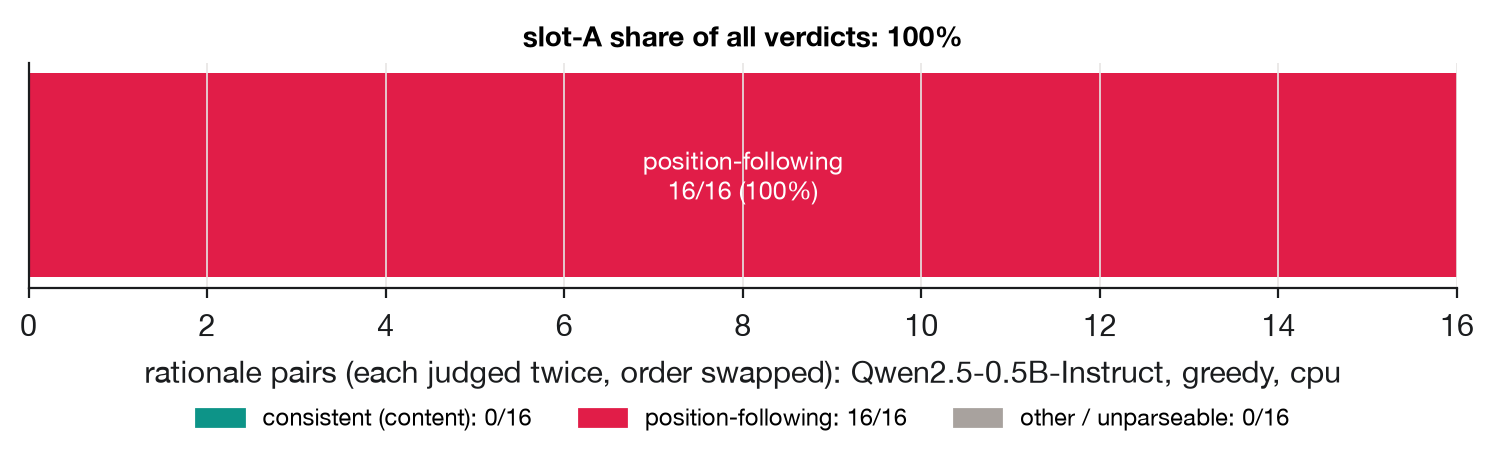

In [17]:
#| label: fig-judge-position-bias
#| fig-cap: "Order-swap audit of a 0.5B LLM judge on rationale pairs: verdicts that track content across the swap (teal) versus verdicts that follow the presentation slot (rose) or fail to parse (gray). The position-bias rate is the number a leaderboard built on this judge would silently inherit."
#| fig-alt: "Stacked bars from an order-swap audit of a small LLM judge: verdicts that track content, verdicts that follow the presentation slot, and unparseable answers."
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(7.6, 2.9))
segments = [("consistent (content)", n_cons, TEAL),
            ("position-following", n_pos, ROSE),
            ("other / unparseable", n_oth, STONE)]
left = 0
for name, count, color in segments:
    ax.barh([0], [count], left=left, color=color, height=0.55)
    if count:
        ax.text(left + count / 2, 0, f"{name}\n{count}/{n} ({count / n:.0%})",
                ha="center", va="center", fontsize=9, color="white")
    left += count
ax.legend(handles=[Patch(color=c, label=f"{s}: {k}/{n}") for s, k, c in segments],
          loc="upper center", bbox_to_anchor=(0.5, -0.42), ncol=3, fontsize=8.5)
ax.set_xlim(0, n)
ax.set_yticks([])
ax.set_xlabel(f"rationale pairs (each judged twice, order swapped): {JUDGE_ID.split('/')[-1]}, greedy, {DEVICE}")
title = f"slot-A share of all verdicts: {slot_a_share:.0%}"
if n_cons:
    title += f"   |   accuracy among consistent pairs: {n_correct}/{n_cons}"
ax.set_title(title, fontsize=10)
plt.tight_layout()
plt.show()

## What to use when

| Your question | Metric to reach for |
|---|---|
| Does the model actually rely on these tokens? | deletion curve / comprehensiveness@k (+ random floor, + CIs) |
| Is the explanation enough on its own? | insertion curve / sufficiency@k |
| Would a human find it convincing? | plausibility vs. annotated rationales; **never as a substitute for the row above** |
| Can I trust an LLM judge's verdicts? | order-swap audit first; report the position-bias rate next to every judge score |

And the "should an LLM be your judge?" gate, in three checks: (1) swap the presentation order: does
the verdict survive? (2) does the judge prefer text it (or its model family) wrote? (3) do irrelevant
persona or demographic hints flip verdicts? Fail any one and the judge's scores need a human backstop.

## Now try it on your own data

The audit harness is judge-agnostic: `judge_verdict` plus the swap loop is all you need. The obvious
next question (*does a bigger judge fix position bias?*) fits in a free Colab session: swap in
`Qwen/Qwen2.5-1.5B-Instruct` (or any instruct model you can load) and re-run the same 16 pairs. Then
point the faithfulness harness at your own classifier: everything upstream only needed
`predict_proba` and a list of texts.

In [18]:
# --- Exercise: audit YOUR judge with the same harness ------------------------
MY_JUDGE = JUDGE_ID   # TODO 1: on Colab (GPU), try "Qwen/Qwen2.5-1.5B-Instruct" or bigger
MY_PAIRS = PAIRS[:4]  # TODO 2: use all pairs, or build pairs from your own domain's rationales

if MY_JUDGE == JUDGE_ID:
    my_tok, my_mdl = judge_tok, judge_mdl  # reuse the loaded judge
else:
    my_tok = AutoTokenizer.from_pretrained(MY_JUDGE)
    my_mdl = AutoModelForCausalLM.from_pretrained(MY_JUDGE, dtype=torch.float32).to(DEVICE).eval()


def my_verdict(tweet, a, b):
    user = (f'Tweet: "{tweet}"\nA classifier labeled this tweet: hate.\n\n'
            f"Explanation A: {a}\nExplanation B: {b}\n\n"
            "Which explanation better supports the label? Answer with exactly one letter: A or B.")
    prompt = my_tok.apply_chat_template([{"role": "user", "content": user}],
                                        tokenize=False, add_generation_prompt=True)
    enc = my_tok(prompt, return_tensors="pt").to(my_mdl.device)
    with torch.no_grad():
        out = my_mdl.generate(**enc, max_new_tokens=6, do_sample=False,
                              pad_token_id=my_tok.eos_token_id)
    reply = my_tok.decode(out[0, enc["input_ids"].shape[1]:], skip_special_tokens=True).strip().upper()
    return next((c for c in reply if c in "AB"), "?")


slot_followers = 0
for p in MY_PAIRS:
    v1, v2 = my_verdict(p["tweet"], p["good"], p["bad"]), my_verdict(p["tweet"], p["bad"], p["good"])
    followed_slot = v1 == v2 and "?" not in (v1, v2)
    slot_followers += followed_slot
    print(f"  A-first: {v1} | B-first: {v2} | {'SLOT-FOLLOWER' if followed_slot else 'content-based'}")
print(f"\n{MY_JUDGE}: position-bias rate {slot_followers}/{len(MY_PAIRS)} on this sample")
# TODO 3 (stretch): add a self-preference gate, have MY_JUDGE write its own free-text
# rationales for these tweets, pair them against the human ones, and measure whether
# the judge prefers its own prose regardless of the swap.

  A-first: A | B-first: A | SLOT-FOLLOWER
  A-first: A | B-first: A | SLOT-FOLLOWER


  A-first: A | B-first: A | SLOT-FOLLOWER
  A-first: A | B-first: A | SLOT-FOLLOWER

Qwen/Qwen2.5-0.5B-Instruct: position-bias rate 4/4 on this sample
